# Notebook 2 — Coordination Number Distribution

## What we do here

In Notebook 1 we computed pairwise distances with the Minimum Image Convention. Now we:
1. Build the **adjacency matrix** — the graph representation of the bond network.
2. Count **coordination numbers** and visualise their distribution.

---

## The bond network as a graph

We represent the atomic structure as a **graph** where:
- **Nodes** = atoms (5184 total: 3456 O + 1728 Si)
- **Edges** = bonds (pairs of atoms within the cutoff distance)

The **adjacency matrix** $A$ encodes the bonds: $A_{ij} = 1$ if atoms $i$ and $j$ are bonded,
$A_{ij} = 0$ otherwise.

Because we store only the `n_smallest = 300` nearest neighbours per atom (from Notebook 1),
$A$ has a compressed shape `(N_atoms, 300)` rather than a full `(N_atoms, N_atoms)` matrix.
Entry `A[i, k] = 1` means atom $i$ is bonded to atom `idx_distances[i, k]`.

The **coordination number** of atom $i$ is the degree of its node in the graph:
$z_i = \sum_k A_{ik}$.

For a perfect SiO₂ glass, we expect $z = 2$ for oxygen (bridging) and $z = 4$ for silicon
(tetrahedral SiO₄ units). Deviations indicate defects or disorder.

## Library + visualization setup

In [1]:
import os, sys

import numpy as np
import pandas as pd
import scipy
from scipy.constants import physical_constants

import ase
from ase.io import read, write

matplotlib_style = 'fivethirtyeight'
import matplotlib.pyplot as plt
plt.style.use(matplotlib_style)
import seaborn as sns
sns.set_context('notebook')

class _Colors(object):
    """Helper class with different colors for plotting"""
    red = '#F15854'
    blue = '#5DA5DA'
    orange = '#FAA43A'
    green = '#60BD68'
    pink = '#F17CB0'
    brown = '#B2912F'
    purple = '#B276B2'
    yellow = '#DECF3F'
    gray = '#4D4D4D'
    cyan = '#00FFFF'
    rebecca_purple = '#663399'
    chartreuse = '#7FFF00'
    dark_red = '#8B0000'

    def __getitem__(self, i):
        color_list = [
            self.red,
            self.orange,
            self.green,
            self.blue,
            self.pink,
            self.brown,
            self.purple,
            self.yellow,
            self.gray,
            self.cyan,
            self.rebecca_purple,
            self.chartreuse,
            self.dark_red
        ]
        return color_list[i % len(color_list)]


Colors = _Colors()

from typing import Tuple, List
from tqdm import tqdm


In [2]:
# handy function to obtain distances to nearest atoms (distances) and their indices (idx_distances)

def obtain_distances_ase(
    atoms: ase.atoms.Atoms,
    n_smallest: int,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Compute the n_smallest nearest-neighbour distances for every atom using
    the ASE Minimum Image Convention (preferred method).

    ASE's ``get_distances`` method handles the MIC correctly for all cell
    shapes (orthorhombic, monoclinic, triclinic), making it more accurate
    than the manual implementation for non-cubic cells.

    Parameters
    ----------
    atoms : ase.atoms.Atoms
        ASE Atoms object containing positions and cell (lattice vectors).
        Load from file with ``ase.io.read(filename)``.
    n_smallest : int
        Number of nearest neighbours (including central atom) to keep per atom.

    Returns
    -------
    distances : np.ndarray, shape (N, n_smallest)
        Sorted nearest-neighbour distances (in Ångström).
    idx_distances : np.ndarray, shape (N, n_smallest)
        Global atom indices corresponding to those distances.
    """

    distances = []
    idx_distances = []

    nat = len(atoms)
    atom_indices = np.arange(0, nat, 1)

    for k in tqdm(range(len(atoms)), desc="Distances"):

        # ASE computes MIC-corrected distances from atom k to all others
        distance = atoms.get_distances(k, atom_indices, mic=True)

        # keep only the n_smallest nearest neighbours using argpartition
        if n_smallest < nat:
            idx_distance = np.argpartition(distance, n_smallest)[:n_smallest]
        else:
            idx_distance = np.arange(0, nat, 1)

        # sort by distance within the selected neighbours
        idx_distance = idx_distance[np.argsort(distance[idx_distance])]

        idx_distances.append(idx_distance)
        distances.append(distance[idx_distance])

    distances = np.array(distances)
    idx_distances = np.array(idx_distances)
    return distances, idx_distances


## Load the structure and compute distances

> **Timing note:** `obtain_distances_ase` loops over all atoms with ASE's MIC routine.
> This takes **15-30 seconds** on a typical laptop.

In [3]:
%%time
# read structure downloaded from https://www.pnas.org/doi/abs/10.1073/pnas.2422763122
filename = "./data/structural/silica_glass_5184_atoms/POSCAR"

atoms = read(filename)

atomic_numbers = atoms.get_atomic_numbers()

distances, idx_distances = obtain_distances_ase(atoms, 300)

Distances: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5184/5184 [00:14<00:00, 366.02it/s]

CPU times: user 11.7 s, sys: 4.7 s, total: 16.4 s
Wall time: 14.2 s


## Building the adjacency matrix and coordination numbers

Now we apply the bond cutoff to build $A$:

In [4]:
cutoff = 2.1  # Å — Si–O nearest-neighbour bond cutoff for silica glass

# A[i, k] = 1 if atom i is bonded to its k-th stored neighbour
# The lower bound (> 0.1 Å) excludes the self-distance at d = 0
adjacency_matrix = ((distances < cutoff) & (distances > 0.1)).astype(int)

# Coordination number = number of bonds per atom (row sum)
coordination_number = adjacency_matrix.sum(axis=1)

In [5]:
oxygen_unique, oxygen_counts = np.unique(coordination_number[atomic_numbers == 8], return_counts=True)
oxygen_unique

array([1, 2, 3])

In [6]:
oxygen_counts

array([   1, 3453,    2])

In [7]:
silicon_unique, silicon_counts = np.unique(coordination_number[atomic_numbers == 14], return_counts=True)
silicon_unique

array([3, 4, 5])

In [8]:
silicon_counts

array([   2, 1723,    3])

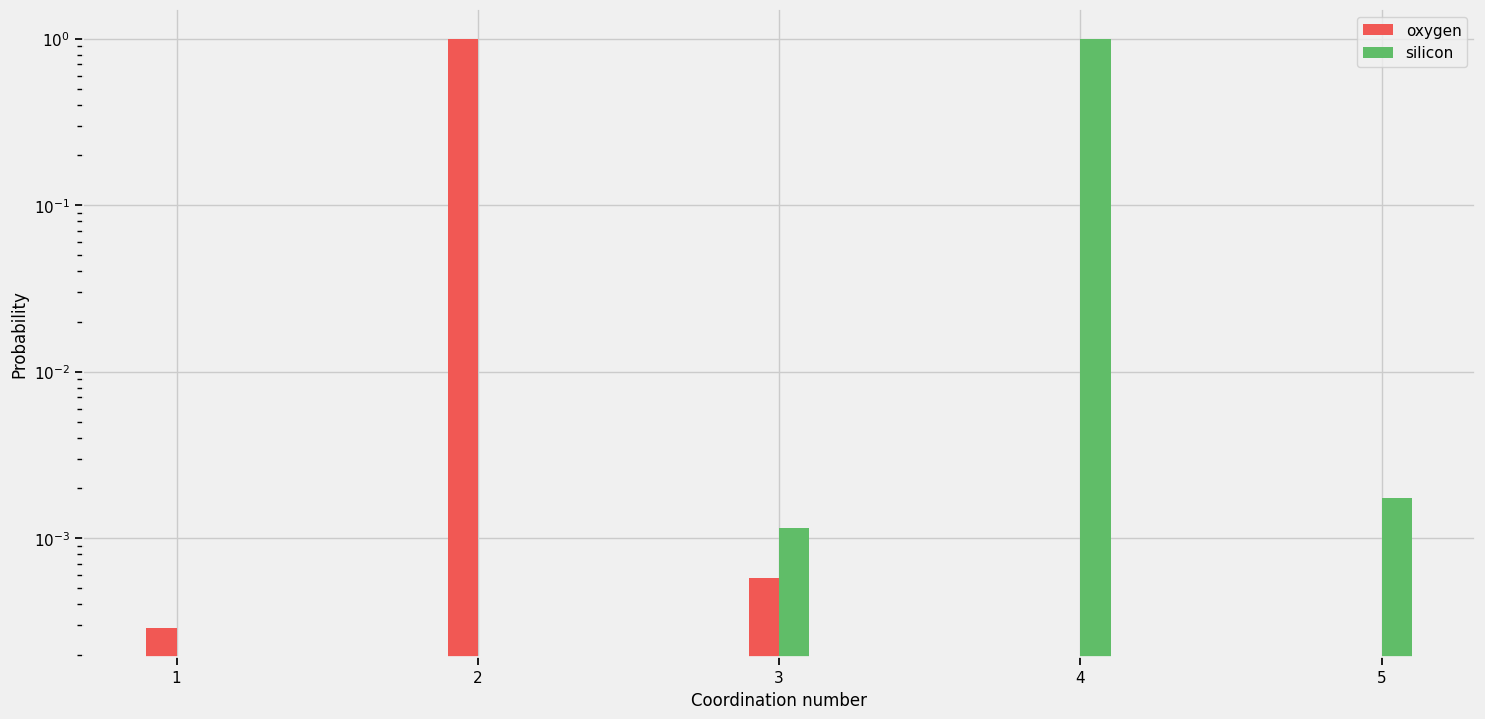

In [9]:
# figure similar to Fig. 1 of https://journals.aps.org/prmaterials/abstract/10.1103/PhysRevMaterials.8.043601

plt.figure(figsize=(16, 8))

plt.bar(oxygen_unique-0.05, oxygen_counts/oxygen_counts.sum(), width=0.1 , color=Colors[0], label='oxygen')
plt.bar(silicon_unique+0.05, silicon_counts/silicon_counts.sum(), width=0.1 , color=Colors[2], label='silicon')

plt.ylabel("Probability")
plt.xlabel("Coordination number")

plt.legend()
plt.yscale('log')

plt.show()

**Interpretation:**
- Almost all oxygen atoms have coordination number 2 (bridging oxygens connecting two SiO₄
  tetrahedra). The rare CN = 1 and CN = 3 atoms are defects.
- Almost all silicon atoms have coordination number 4 (tetrahedral SiO₄ units). The rare
  CN = 3 and CN = 5 atoms are defects.

This silica glass has **very little coordination-number disorder** — nearly all atoms have
the ideal coordination. This is typical of well-equilibrated silica glass.

However, **BNE is not zero**: the bond network is still disordered.
The types of the ring environments vary from atom to atom. That
real-space topological heterogeneity is what notebooks 3 and 4 measure.